## 1. Setup

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-05-16 04:59:37.940487: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778907578.388470      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778907578.530647      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778907579.646435      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778907579.646491      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778907579.646495      57 computation_placer.cc:177] computation placer alr

## 2. Load Dataset (MNIST)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


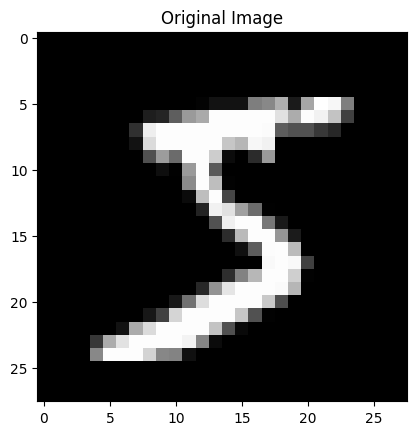

In [2]:
(x_train, _), _ = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1]
x_train = (x_train.astype("float32") / 127.5) - 1.0
x_train = np.expand_dims(x_train, axis=-1)

print(x_train.shape)

plt.imshow(x_train[0].squeeze(), cmap='gray')
plt.title("Original Image")
plt.show()

## 3. Forward Process (Adding Noise)

In [3]:
def add_noise(x, t):
    noise = torch.randn_like(x)
    return torch.sqrt(1 - t) * x + torch.sqrt(t) * noise, noise

## 4. Visualize Noise Levels

I0000 00:00:1778907619.397878      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778907619.404301      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


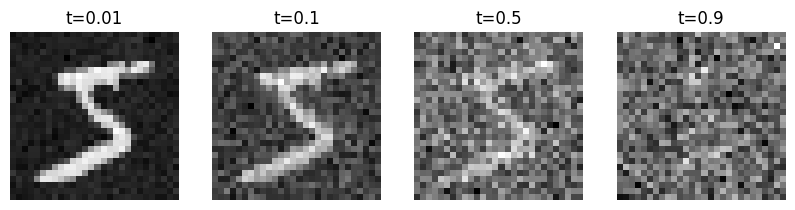

In [4]:
def add_noise(x, t):
    noise = tf.random.normal(shape=tf.shape(x))
    t = tf.reshape(t, (-1, 1, 1, 1))
    noisy = tf.sqrt(1 - t) * x + tf.sqrt(t) * noise
    return noisy, noise

t_values = [0.01, 0.1, 0.5, 0.9]

plt.figure(figsize=(10,3))

for i, t in enumerate(t_values):
    noisy, _ = add_noise(x_train[0:1], tf.constant([t], dtype=tf.float32))
    plt.subplot(1, len(t_values), i+1)
    plt.imshow(noisy[0].numpy().squeeze(), cmap='gray')
    plt.title(f"t={t}")
    plt.axis('off')

plt.show()

## 5. Simple Denoising Model

In [5]:
def build_model():
    input_img = tf.keras.Input(shape=(28, 28, 1))
    input_t = tf.keras.Input(shape=(1,))

    # Flatten image
    x = tf.keras.layers.Flatten()(input_img)

    # Concatenate timestep
    x = tf.keras.layers.Concatenate()([x, input_t])

    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dense(28*28)(x)

    output = tf.keras.layers.Reshape((28, 28, 1))(x)

    return tf.keras.Model([input_img, input_t], output)

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 785)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    402,432 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 784)       │    402,192 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28, 1) │          0 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 804,624 (3.07 MB)

 Trainable params: 804,624 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Training (Predicting Noise)

In [6]:
optimizer = tf.keras.optimizers.Adam(1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()

batch_size = 64
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(10000).batch(batch_size)

epochs = 10

for epoch in range(epochs):
    for batch in dataset:
        t = tf.random.uniform((batch.shape[0], 1), 0, .8)

        noisy, noise = add_noise(batch, t)

        with tf.GradientTape() as tape:
            pred_noise = model([noisy, t], training=True)
            loss = loss_fn(noise, pred_noise)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    print(f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}")

Epoch 1, Loss: 0.9338
Epoch 2, Loss: 0.8265
Epoch 5, Loss: 0.7396
Epoch 6, Loss: 0.7196
Epoch 7, Loss: 0.7443
Epoch 8, Loss: 0.7168
Epoch 9, Loss: 0.7248
Epoch 10, Loss: 0.7246


## 7. Test Denoising

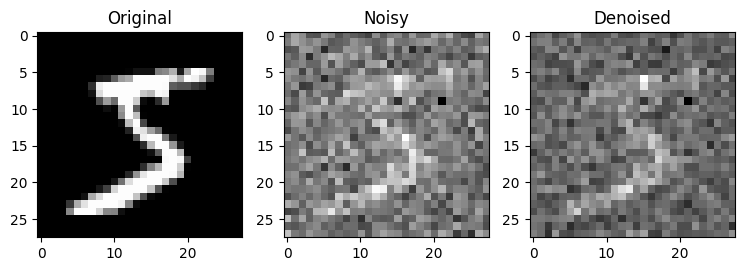

In [7]:
test_img = x_train[0:1]
t = tf.constant([[0.5]])

noisy, noise = add_noise(test_img, t)

pred_noise = model([noisy, t], training=False)
denoised = noisy - pred_noise

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(test_img[0].squeeze(), cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(noisy[0].numpy().squeeze(), cmap='gray')
plt.title("Noisy")

plt.subplot(1,3,3)
plt.imshow(denoised[0].numpy().squeeze(), cmap='gray')
plt.title("Denoised")

plt.show()

## 8. Simple Sampling

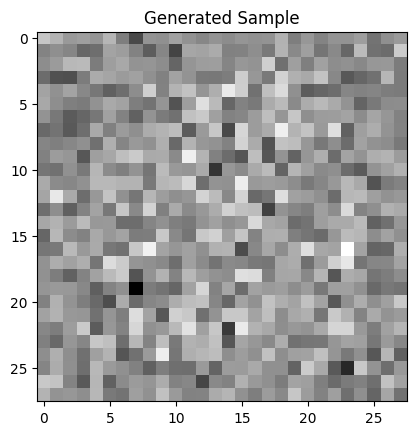

In [8]:
x = tf.random.normal((1, 28, 28, 1))

steps = 10

for i in reversed(range(steps)):
    t = tf.constant([[i/steps]], dtype=tf.float32)
    pred_noise = model([x, t], training=False)
    x = x - pred_noise

plt.imshow(x[0].numpy().squeeze(), cmap='gray')
plt.title("Generated Sample")
plt.show()